# Preliminary Visualizations of U.S. Mass Shooting Data

This notebook presents initial visualizations of U.S. mass shooting data before machine learning modeling.

### Importing Libraries

In [79]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

warnings.filterwarnings("ignore")

## Historical Mass Shooting Incidents

### Load Dataset

In [80]:
df = pd.read_csv("data/mass_shootings_historical.csv")
df.head()

,Date,City,State,Dead,Injured,Total,Description
0,31-07-2022,Decatur,Illinois,1,3,4,"Four teenagers, one of whom died, were shot at..."
1,31-07-2022,Hartford,Connecticut,0,4,4,"Four people, including a teenager, were shot i..."
2,31-07-2022,Indianapolis,Indiana,0,4,4,Four people were shot after a fight in the Bro...
3,31-07-2022,Detroit,Michigan,1,7,8,"One person was killed, and seven others were i..."
4,31-07-2022,Orlando,Florida,0,7,7,Seven people were shot when someone opened fir...


### Initial Dataset Inspection

In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2712 entries, 0 to 2711
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         2712 non-null   object
 1   City         2712 non-null   object
 2   State        2712 non-null   object
 3   Dead         2712 non-null   int64 
 4   Injured      2712 non-null   int64 
 5   Total        2712 non-null   int64 
 6   Description  2712 non-null   object
dtypes: int64(3), object(4)
memory usage: 148.4+ KB


In [82]:
df.describe()

,Dead,Injured,Total
count,2712.000000,2712.000000,2712.000000
mean,1.436578,4.401180,5.837021
std,2.880447,8.532826,10.130793
min,0.000000,0.000000,2.000000
25%,0.000000,3.000000,4.000000
50%,1.000000,4.000000,4.000000
75%,2.000000,5.000000,6.000000
max,61.000000,411.000000,472.000000


### Date Formatting

In [83]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")
df["year"] = df["Date"].dt.year

df.head()

,Date,City,State,Dead,Injured,Total,Description,year
0,2022-07-31,Decatur,Illinois,1,3,4,"Four teenagers, one of whom died, were shot at...",2022
1,2022-07-31,Hartford,Connecticut,0,4,4,"Four people, including a teenager, were shot i...",2022
2,2022-07-31,Indianapolis,Indiana,0,4,4,Four people were shot after a fight in the Bro...,2022
3,2022-07-31,Detroit,Michigan,1,7,8,"One person was killed, and seven others were i...",2022
4,2022-07-31,Orlando,Florida,0,7,7,Seven people were shot when someone opened fir...,2022


## Visualizations

### Visualization 1: Total Victim Counts Over Time

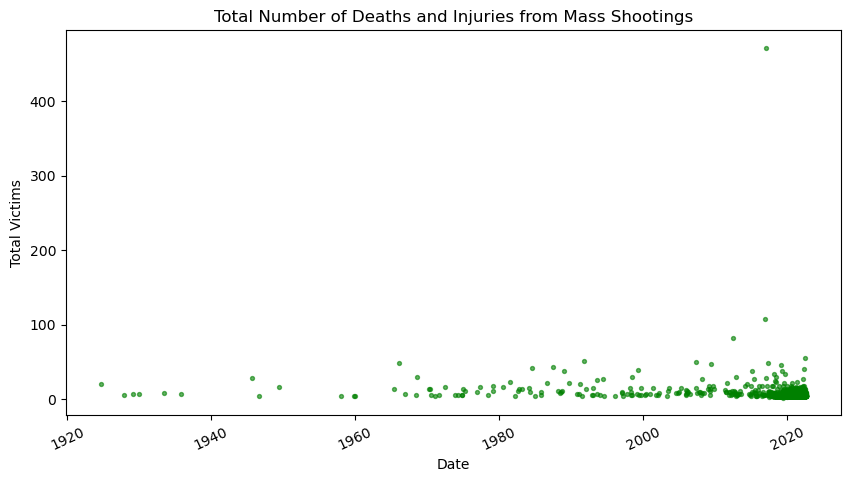

In [84]:
# Plot the total number of deaths and injuries from mass shootings from 1924 to 2022

plt.figure(figsize=(10, 5))

plt.scatter(df["Date"], df["Total"], color="green", s=8, alpha=0.6)

plt.title("Total Number of Deaths and Injuries from Mass Shootings")
plt.xlabel("Date")
plt.ylabel("Total Victims")
plt.xticks(rotation=25)

plt.show()

### Visualization 2: Mass Shooting Events by State

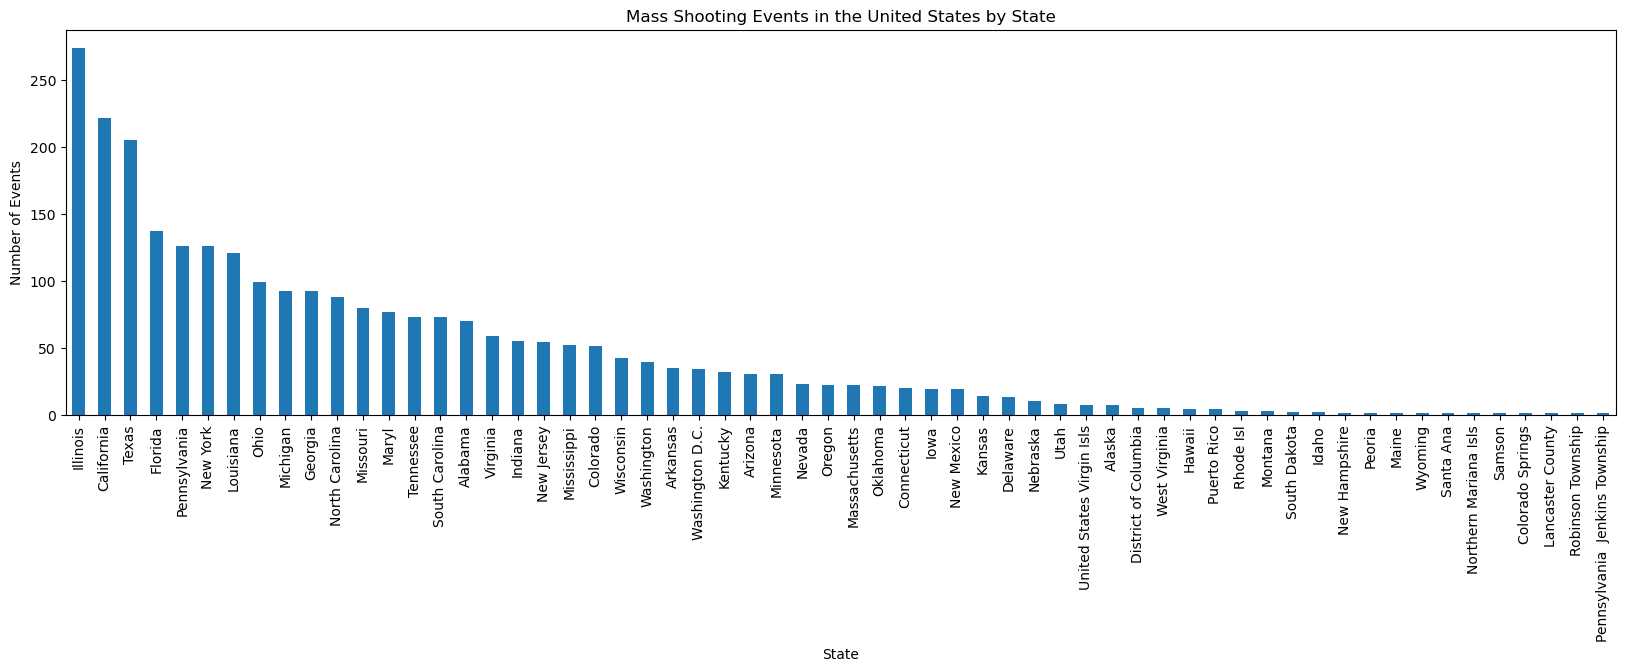

In [85]:
# Plot the number of mass shooting events by state

state_counts = df["State"].value_counts()

state_counts.plot(
    kind="bar",
    figsize=(20, 5),
    title="Mass Shooting Events in the United States by State"
)

plt.xlabel("State")
plt.ylabel("Number of Events")
plt.show()

### Visualization 3: Deaths and Injuries by State

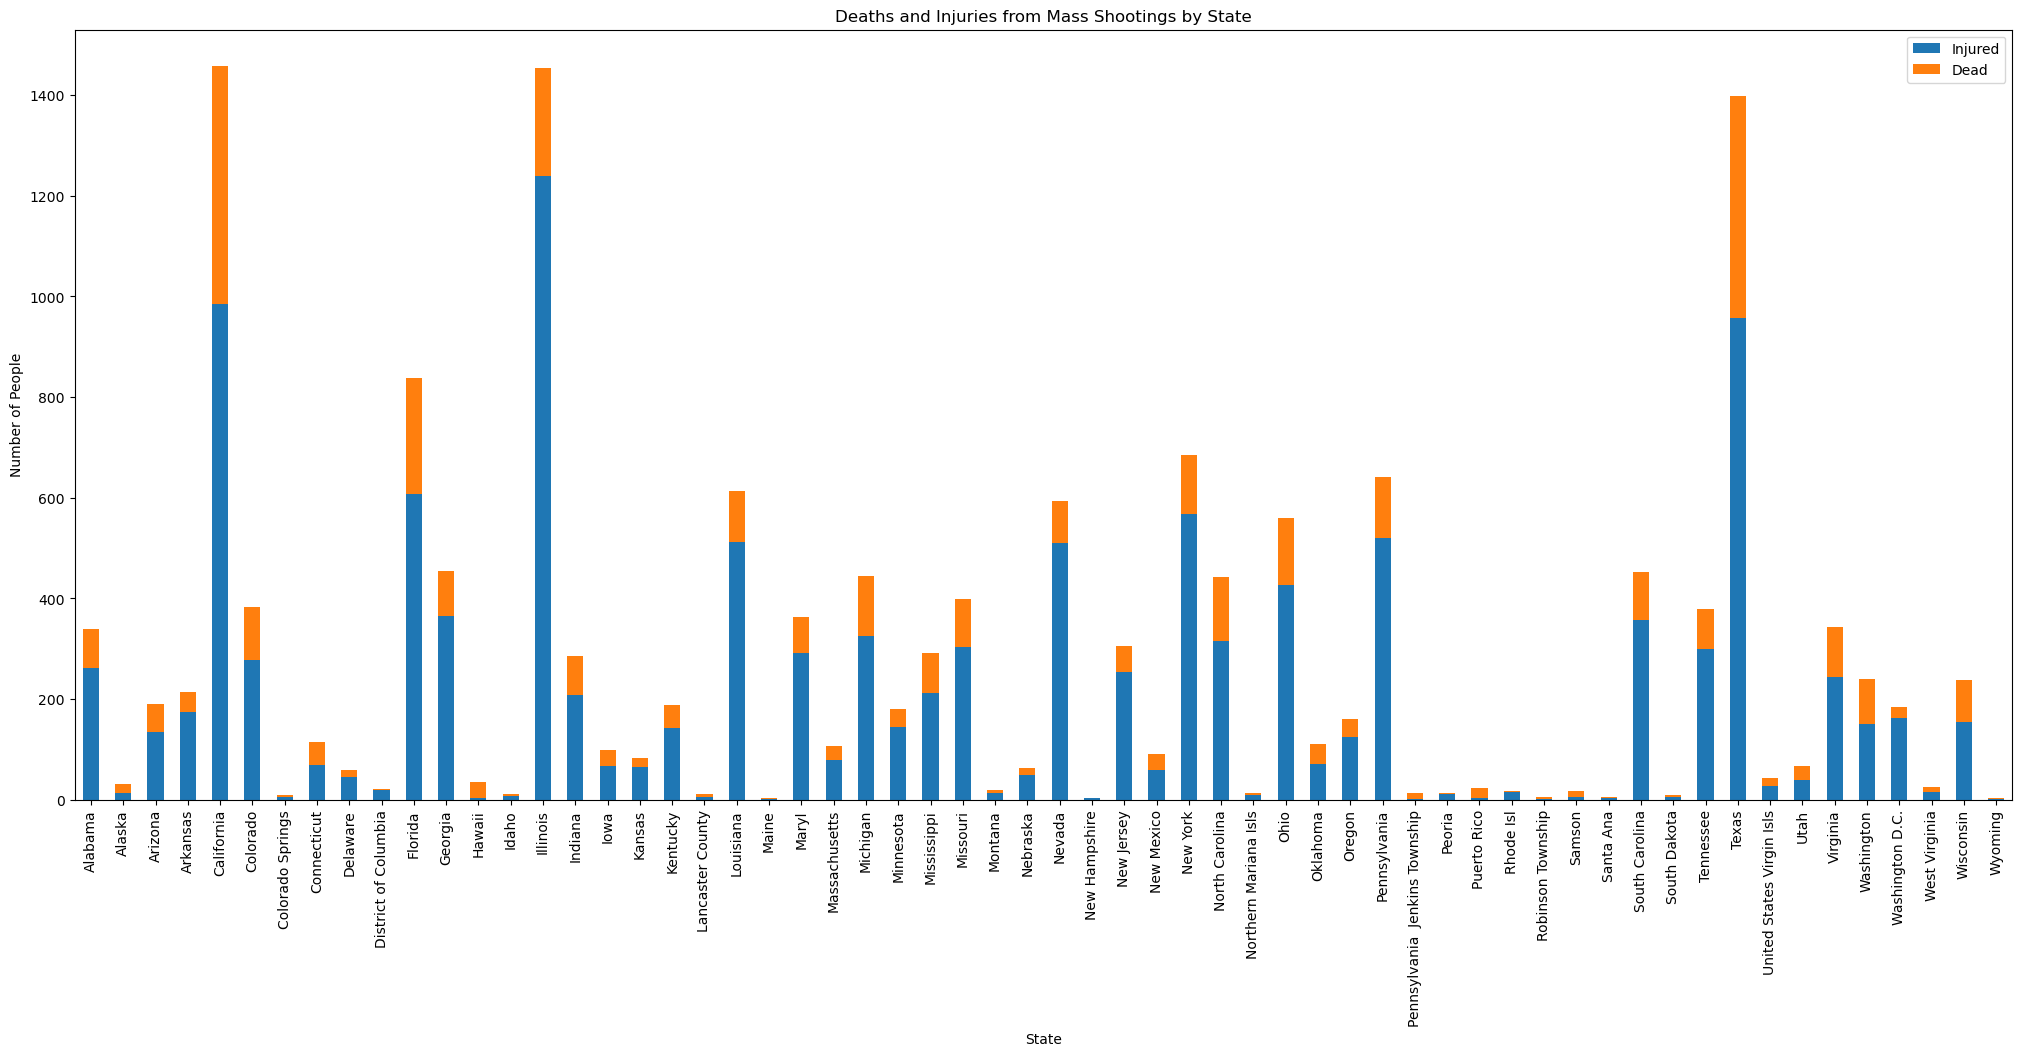

In [86]:
# Plot total injuries and deaths by state

injured_dead = df.groupby("State")[["Injured", "Dead"]].sum()

injured_dead.plot(
    kind="bar",
    stacked=True,
    figsize=(25, 10),
    title="Deaths and Injuries from Mass Shootings by State"
)

plt.xlabel("State")
plt.ylabel("Number of People")
plt.show()

### Filter Dataset to 1990-2021

In [87]:
# Create a filtered dataset for visualizations from 1990 to 2021
df_1990_2021 = df[(df["year"] >= 1990) & (df["year"] <= 2021)]

df_1990_2021.head()

,Date,City,State,Dead,Injured,Total,Description,year
441,2021-12-31,Los Angeles,California,0,6,6,Six shoppers were wounded at a grocery superma...,2021
442,2021-12-31,Capitol Heights,Maryl,0,4,4,An adult and three juveniles were wounded in a...,2021
443,2021-12-31,Gulfport,Mississippi,4,3,7,"During an outdoor New Year's Eve party, a phys...",2021
444,2021-12-30,Philadelphia,Pennsylvania,0,6,6,Six shooters opened fire on a busy street with...,2021
445,2021-12-30,Kirksville,Missouri,2,2,4,An adult and infant were killed and two adults...,2021


### Visualization 4: Mass Shootings Per Year, 1990-2021

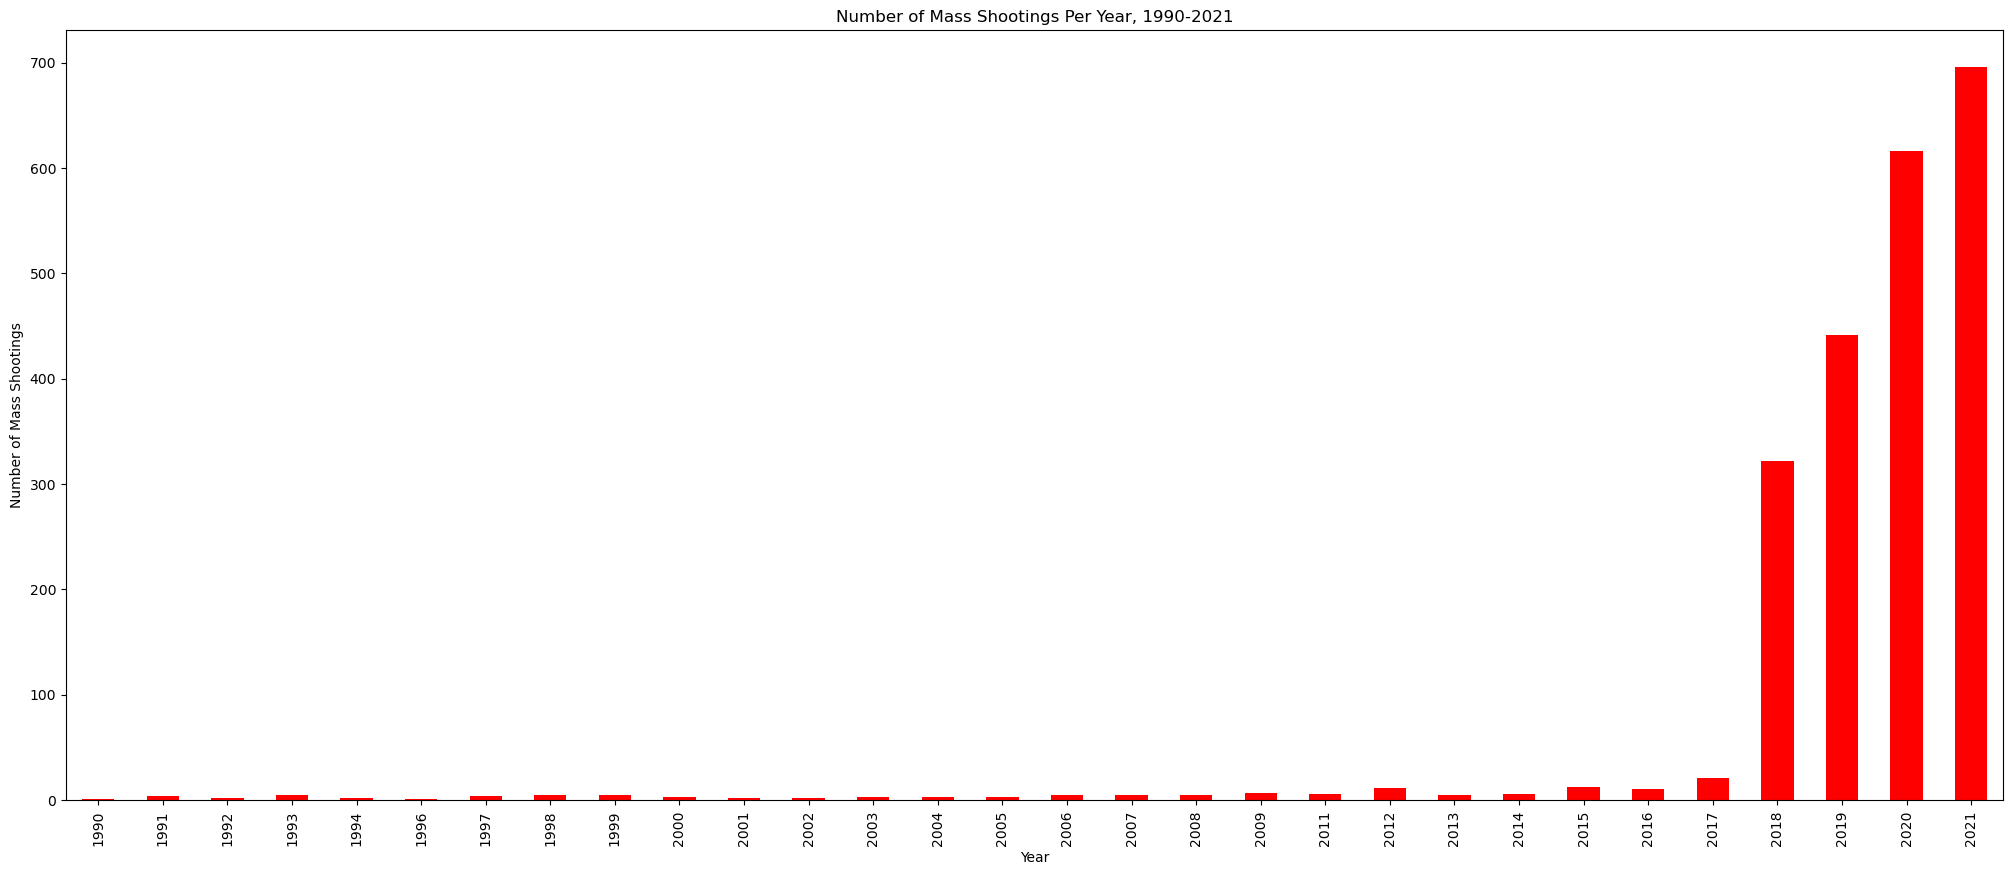

In [88]:
# Plot the number of mass shooting events by year from 1990 to 2021

year_counts = df_1990_2021["year"].value_counts().sort_index()

year_counts.plot(
    kind="bar",
    figsize=(25, 10),
    color="red",
    title="Number of Mass Shootings Per Year, 1990-2021"
)

plt.xlabel("Year")
plt.ylabel("Number of Mass Shootings")
plt.show()

### Prepare State Data for Mapping

In [93]:
# Create state abbreviations for mapping

state_code = {
    "Alabama": "AL", "Alaska": "AK", "Arizona": "AZ", "Arkansas": "AR",
    "California": "CA", "Colorado": "CO", "Connecticut": "CT", "Delaware": "DE",
    "Florida": "FL", "Georgia": "GA", "Hawaii": "HI", "Idaho": "ID",
    "Illinois": "IL", "Indiana": "IN", "Iowa": "IA", "Kansas": "KS",
    "Kentucky": "KY", "Louisiana": "LA", "Maine": "ME", "Maryland": "MD",
    "Massachusetts": "MA", "Michigan": "MI", "Minnesota": "MN",
    "Mississippi": "MS", "Missouri": "MO", "Montana": "MT", "Nebraska": "NE",
    "Nevada": "NV", "New Hampshire": "NH", "New Jersey": "NJ",
    "New Mexico": "NM", "New York": "NY", "North Carolina": "NC",
    "North Dakota": "ND", "Ohio": "OH", "Oklahoma": "OK", "Oregon": "OR",
    "Pennsylvania": "PA", "Rhode Island": "RI", "South Carolina": "SC",
    "South Dakota": "SD", "Tennessee": "TN", "Texas": "TX", "Utah": "UT",
    "Vermont": "VT", "Virginia": "VA", "Washington": "WA",
    "West Virginia": "WV", "Wisconsin": "WI", "Wyoming": "WY"
}

df_1990_2021 = df_1990_2021.copy()
df_1990_2021["state_code"] = df_1990_2021["State"].map(state_code)

### Visualization 5: Total Deaths by State, 1990-2021

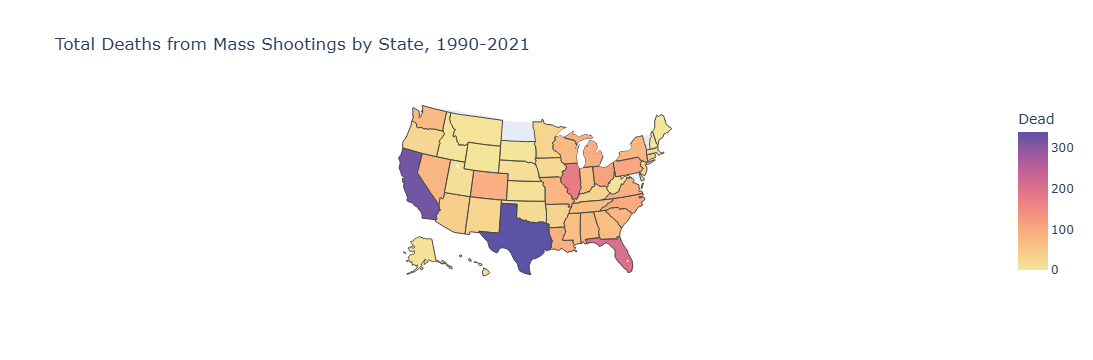

In [90]:
# Plot total deaths by state from 1990 to 2021
state_data = df_1990_2021.groupby("state_code", as_index=False)[["Dead", "Injured", "Total"]].sum()

fig = px.choropleth(
    state_data,
    locations="state_code",
    locationmode="USA-states",
    scope="usa",
    color="Dead",
    color_continuous_scale="sunset",
    title="Total Deaths from Mass Shootings by State, 1990-2021"
)

fig.show()

### Visualization 6: Total Victims by State, 1990-2021

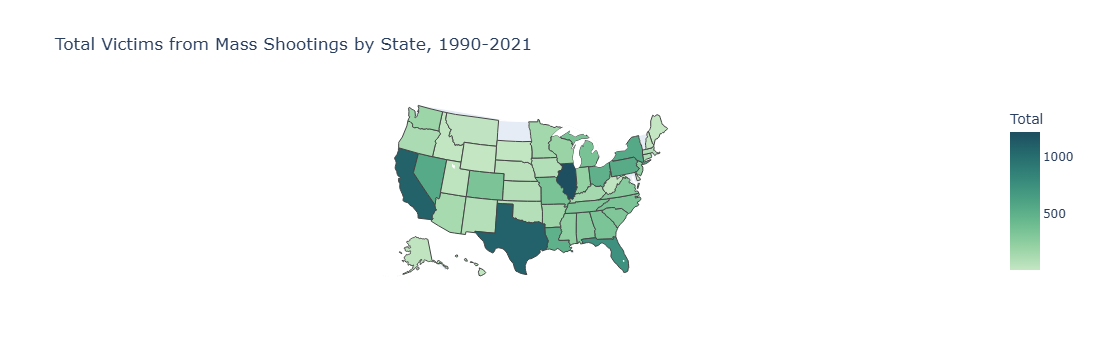

In [92]:
# Plot total victims by state from 1990 to 2021

fig = px.choropleth(
    state_data,
    locations="state_code",
    locationmode="USA-states",
    scope="usa",
    color="Total",
    color_continuous_scale="blugrn",
    title="Total Victims from Mass Shootings by State, 1990-2021"
)

fig.show()

## Initial Takeaways

This notebook presents initial visualizations of U.S. mass shooting data before machine learning modeling.